# K-Nearest Neighbors (KNN): Introduction

In this lecture, we learn **K-nearest neighbors (KNN)**, one of the simplest and most intuitive **supervised learning** methods.

We will use two input variables:

- `AnnualIncome`
- `AnnualSpending`

to classify customers into three groups:

- **Low-Value Customer**
- **Mid-Value Customer**
- **High-Value Customer**

## Learning Objectives

By the end of this lecture, you should be able to:

- explain why KNN is a **supervised learning** method
- explain the basic idea of **nearest neighbors**
- understand the role of **k** and how it impacts accuracy
- understand why **feature scaling** is important in KNN
- build a simple KNN model in Python
- interpret the **accuracy**, **precision**, **recall**, and **confusion matrix**

## 1. Why is KNN a supervised learning method?

In supervised learning, we have:

- input variables `X`
- a known output variable `y`

The goal is to use past labeled data to predict the output for a new observation.

In our example:

- `X` = `AnnualIncome`, `AnnualSpending`
- `y` = `CustomerValueCategory`

Because the training data already contains the correct customer category, KNN is a **supervised learning** method.

**Important note:** unlike regression, in **KNN classification** the target variable `y` should be **categorical**.

## 2. Basic idea of KNN

KNN predicts the class of a new observation by looking at the **nearest observations** in the training data.

Suppose a new customer has:

- `AnnualIncome = 77,000`
- `AnnualSpending = 55,000`

If the 3 nearest customers are:

- Low-Value Customer
- Mid-Value Customer
- High-Value Customer

then KNN predicts:

- **Mid-Value Customer**

So the main idea is:

> A new observation is classified based on the classes of the nearest observations.

## 3. What does `k` mean?

The `k` in KNN is the number of neighbors used for prediction.

Examples:

- `k = 1` → use only 1 nearest neighbor
- `k = 3` → use the 3 nearest neighbors
- `k = 5` → use the 5 nearest neighbors

General idea:

- small `k` → more sensitive to noise
- large `k` → smoother prediction

In this lecture, we use `k = 3`.

## 4. Why do we scale the features?

KNN uses **distance**.

If one variable has a much larger scale than another variable, it can dominate the distance calculation. That is why feature scaling is important in KNN.

In Python, we often use `StandardScaler()`.

## 5. Python Example

We now build a simple KNN model.

We use:

- `AnnualIncome`
- `AnnualSpending`

to classify customers into:

- Low-Value Customer
- Mid-Value Customer
- High-Value Customer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Create one simple customer dataset.
# The points are intentionally not perfectly separated.
# In real classification problems, classes usually overlap.

customer_df = pd.DataFrame({
    "AnnualIncome": [
        42000, 54000, 76000, 50000, 52000, 71000,
        55000, 82000, 92000, 62000, 63000, 68000,
        70000, 48000, 104000, 78000, 76000, 86000,
        85000, 88000, 70000, 58000, 57000, 98000,
        67000, 65000, 80000, 74000, 60000, 62000,
        46000, 79000, 61000, 81000, 90000, 74000
    ],
    "AnnualSpending": [
        18000, 42000, 74000, 22000, 52000, 41000,
        30000, 47000, 76000, 26000, 48000, 61000,
        34000, 36000, 83000, 29000, 50000, 64000,
        32000, 55000, 60000, 24000, 46000, 70000,
        27000, 45000, 69000, 36000, 39000, 54000,
        38000, 43000, 58000, 33000, 52000, 65000
    ],
    "CustomerValueCategory": [
        "Low-Value Customer", "Mid-Value Customer", "High-Value Customer", "Low-Value Customer", "High-Value Customer", "Mid-Value Customer",
        "Low-Value Customer", "Mid-Value Customer", "High-Value Customer", "Low-Value Customer", "Mid-Value Customer", "High-Value Customer",
        "Low-Value Customer", "Mid-Value Customer", "High-Value Customer", "Low-Value Customer", "Mid-Value Customer", "High-Value Customer",
        "Low-Value Customer", "Mid-Value Customer", "High-Value Customer", "Low-Value Customer", "Mid-Value Customer", "High-Value Customer",
        "Low-Value Customer", "Mid-Value Customer", "High-Value Customer", "Low-Value Customer", "Mid-Value Customer", "High-Value Customer",
        "Low-Value Customer", "Mid-Value Customer", "High-Value Customer", "Low-Value Customer", "Mid-Value Customer", "High-Value Customer"
    ]
})

customer_df


,AnnualIncome,AnnualSpending,CustomerValueCategory
0,42000,18000,Low-Value Customer
1,54000,42000,Mid-Value Customer
2,76000,74000,High-Value Customer
3,50000,22000,Low-Value Customer
4,52000,52000,High-Value Customer
5,71000,41000,Mid-Value Customer
6,55000,30000,Low-Value Customer
7,82000,47000,Mid-Value Customer
8,92000,76000,High-Value Customer
9,62000,26000,Low-Value Customer


This is a small **hand-made dataset** created only for learning KNN.



The dataset is still kept simple so that the ideas of:

- features `X`
- categorical target `y`
- training/testing split
- nearest neighbors
- confusion matrix

are easy to see.


In [3]:
# Check how many customers are in each class.
customer_df["CustomerValueCategory"].value_counts()

,count
CustomerValueCategory,
Low-Value Customer,12
Mid-Value Customer,12
High-Value Customer,12


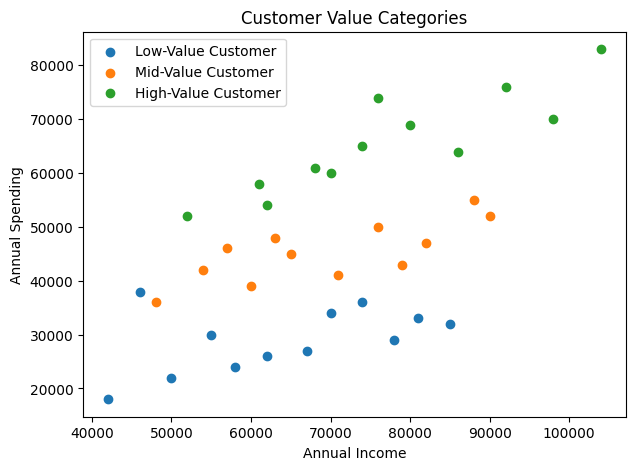

In [4]:
# Create three smaller dataframes for the scatter plot.
low_df = customer_df[customer_df["CustomerValueCategory"] == "Low-Value Customer"]
mid_df = customer_df[customer_df["CustomerValueCategory"] == "Mid-Value Customer"]
high_df = customer_df[customer_df["CustomerValueCategory"] == "High-Value Customer"]

plt.figure(figsize=(7, 5))

# Plot each customer group separately.
plt.scatter(low_df["AnnualIncome"], low_df["AnnualSpending"], label="Low-Value Customer")
plt.scatter(mid_df["AnnualIncome"], mid_df["AnnualSpending"], label="Mid-Value Customer")
plt.scatter(high_df["AnnualIncome"], high_df["AnnualSpending"], label="High-Value Customer")

plt.xlabel("Annual Income")
plt.ylabel("Annual Spending")
plt.title("Customer Value Categories")
plt.legend()
plt.show()


Customers with similar income and spending values are close to each other.

Also notice that the three customer groups are **not perfectly separated** in the scatter plot. That is normal in real data.

This is the main idea behind KNN:

- nearby observations are considered similar
- a new customer is classified based on nearby customers


In [5]:
# X contains the input variables.
X = customer_df[["AnnualIncome", "AnnualSpending"]]

# y contains the target variable. In KNN classification, y should be categorical.
y = customer_df["CustomerValueCategory"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("y is categorical:")
print(y.unique())

X shape: (36, 2)
y shape: (36,)

y is categorical:
['Low-Value Customer' 'Mid-Value Customer' 'High-Value Customer']


In [7]:
# Split the data into training data and testing data.
# stratify=y keeps the class proportions similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=7, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print()
print("Training set class counts:")
print(y_train.value_counts())
print()
print("Testing set class counts:")
print(y_test.value_counts())


X_train shape: (25, 2)
X_test shape: (11, 2)

Training set class counts:
CustomerValueCategory
Mid-Value Customer     9
High-Value Customer    8
Low-Value Customer     8
Name: count, dtype: int64

Testing set class counts:
CustomerValueCategory
High-Value Customer    4
Low-Value Customer     4
Mid-Value Customer     3
Name: count, dtype: int64


We split the data into:

- **training data**: used to build the model
- **testing data**: used to evaluate the model

In [10]:
# Scale the training data and testing data.
# We fit the scaler only on the training data.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # Learn mean/std from X_train, then scale X_train
# Note: Never include test data when using fit or fit_tranform. Use fit_transform on the training subset
# and tranform on the test subset.

X_test_scaled = scaler.transform(X_test) #use the Same mean/std on X_test

In [11]:
# Create the KNN model with k = 3, then fit it on the training data.
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

Here, `n_neighbors=3` means `k = 3`.

The model uses the 3 nearest neighbors to make a prediction.

## 6. Predicting the class of one new customer

Suppose a new customer has:

- `AnnualIncome = 47,000`
- `AnnualSpending = 26,000`

A very simple form is `knn.predict([[47000, 26000]])`, but that is **not the best way here** because:

- it may generate a feature-name warning
- more importantly, our model was trained on **scaled data**

So the better way is to create a DataFrame first, then apply the same scaler, then predict.

In [12]:
# Create one new customer as a DataFrame.
new_customer = pd.DataFrame({
    "AnnualIncome": [47000],
    "AnnualSpending": [26000]
})

# Apply the same scaler used for the training data.
new_customer_scaled = scaler.transform(new_customer)

# Predict the class of the new customer.
predicted_class = knn.predict(new_customer_scaled)

print("Predicted category:", predicted_class[0])

Predicted category: Low-Value Customer


## 7. Evaluate the model on the testing data

To evaluate the model, we predict the classes of the testing data.

In [17]:
# Predict the classes of the testing data.
y_test_pred = knn.predict(X_test_scaled)

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

results_df

,Actual,Predicted
0,Mid-Value Customer,Mid-Value Customer
1,High-Value Customer,High-Value Customer
2,Low-Value Customer,Low-Value Customer
3,Mid-Value Customer,Mid-Value Customer
4,High-Value Customer,High-Value Customer
5,High-Value Customer,High-Value Customer
6,Low-Value Customer,Low-Value Customer
7,Low-Value Customer,Low-Value Customer
8,High-Value Customer,High-Value Customer
9,Mid-Value Customer,Mid-Value Customer


In [18]:
# Compute the accuracy on the testing data.
accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9090909090909091


In [19]:
# Build the confusion matrix.
labels = ["Low-Value Customer", "Mid-Value Customer", "High-Value Customer"]

cm = confusion_matrix(y_test, y_test_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=["Actual: Low", "Actual: Mid", "Actual: High"],
    columns=["Predicted: Low", "Predicted: Mid", "Predicted: High"]
)

cm_df

,Predicted: Low,Predicted: Mid,Predicted: High
Actual: Low,3,1,0
Actual: Mid,0,3,0
Actual: High,0,0,4


## 8. How do we read the confusion matrix?

In the confusion matrix:

- **rows** = actual class
- **columns** = predicted class

The numbers on the **main diagonal** are correct predictions.

A number off the diagonal means the model made a mistake.

## 9. Precision and Recall

**Accuracy** tells us the overall percentage of correct predictions.

But sometimes we need more detail:

- **Precision** = Of all the predictions for a class, how many were correct?
- **Recall** = Of all the actual observations in a class, how many did we correctly predict?

In Python, we use `classification_report()` to see precision, recall, and F1-score for each class.

In [20]:
# Compute precision, recall, and F1-score for each class.
print(classification_report(y_test, y_test_pred))

                     precision    recall  f1-score   support

High-Value Customer       1.00      1.00      1.00         4
 Low-Value Customer       1.00      0.75      0.86         4
 Mid-Value Customer       0.75      1.00      0.86         3

           accuracy                           0.91        11
          macro avg       0.92      0.92      0.90        11
       weighted avg       0.93      0.91      0.91        11



### How to read this report?

- **Precision**: When the model predicts a class, how often is it correct?
- **Recall**: Of all actual instances of a class, how many did the model find?
- **F1-score**: The balance between precision and recall
- **Support**: The number of actual observations in each class

## 10. How does k impact accuracy?

The choice of `k` affects model performance:

| k value | What happens |
|---------|---------------|
| **Too small** (k=1) | Overfits to noise → accuracy can be low |
| **Optimal k** | Best balance → accuracy is highest |
| **Too large** | Underfits, ignores local patterns → accuracy decreases |

There is usually a **sweet spot** for k — not too small, not too large.

Let's test different values of k on our data.

In [22]:
# Test different values of k
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    accuracies.append(acc)
    print(f"k = {k:2d}: Accuracy = {acc:.2f}")

k =  1: Accuracy = 0.82
k =  3: Accuracy = 0.91
k =  5: Accuracy = 0.91
k =  7: Accuracy = 0.82
k =  9: Accuracy = 0.91
k = 11: Accuracy = 0.82
k = 13: Accuracy = 0.73
k = 15: Accuracy = 0.64


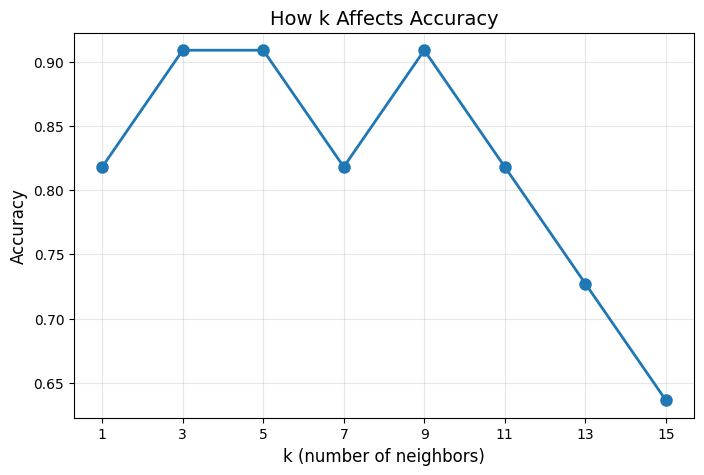

In [23]:
# Plot accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('k (number of neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('How k Affects Accuracy', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

### What do we observe?

- Very small `k` (like k=1) can be sensitive to noise
- Very large `k` may include neighbors that are too far away
- The best `k` is usually somewhere in between

**Tip:** A common starting point is `k = √n` where `n` is the number of training samples.

## 11. Key Points

- KNN is a **supervised learning** method
- in KNN classification, the target variable `y` should be **categorical**
- KNN classifies a new observation based on the **nearest neighbors**
- the value of `k` matters: too small → overfitting, too large → underfitting
- because KNN uses distance, **feature scaling is important**
- we evaluate the model using the **testing data**
- **accuracy** measures overall correctness
- **precision** and **recall** give per-class performance details
- the **confusion matrix** shows correct and incorrect predictions by class